# 03 — Configuration 3 — Indépendance des canaux : PatchTST-CI vs PatchTST-CA

**Question.** Les covariables (réseau, cycliques, géométrie solaire) améliorent-elles la prévision, et comment les injecter ?

**Hypothèses.** **CI** : encodeur partagé, seul le canal cible alimente la tête : les exogènes n'ont aucune influence (équivalent univarié). **CA** : attention inter-canaux à chaque patch : la cible « interroge » les exogènes passés. **X** : les covariables déterministes FUTURES (heure, saison, géométrie solaire de l'instant prévu) corrigent la prévision pas à pas. **g** : porte physique : la prévision est forcée à 0 quand le soleil est couché.

**Paramètres fixés.** P et L retenus aux configurations 1 et 2, H = 24 h.

**Protocole** (identique pour toutes les configurations — module `patchtst_pv`, section 8) :
1. entraînement sur Train (2019–2021), arrêt précoce sur Val (01–09/2022), **5 graines** ;
2. précision sur **toutes les origines horaires du Test** (10/2022–05/2023) : RMSE, MAE, nRMSE = RMSE / moyenne, R², MBE ;
3. **robustesse** : écart-type sur les graines et bruit gaussien 5 % sur les exogènes (rejet si ΔRMSE > 15 %) ;
4. **stabilité** : rolling forecast de 30 jours sans ré-entraînement, dérive = RMSE(J24–30) / RMSE(J1–7) (objectif < 1,2) ;
5. **efficience** : temps d'inférence d'un échantillon (< 100 ms) et taille des poids (< 50 Mo) ;
6. **score de décision** de `projet.md` (brut et normalisé) et tests de Diebold-Mariano contre la persistance et la moyenne.

> Les entraînements sont mis en cache (`cache/<configuration>/`) : supprimer le dossier correspondant relance
> l'entraînement complet depuis ce notebook.

In [1]:
# --- Environnement commun à tous les notebooks -------------------------------
import sys, warnings
from pathlib import Path
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m          # module commun de l'étude (entièrement commenté)
import figures_style as fs       # charte graphique des figures de l'article
fs.appliquer()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analyse as an, organigramme as org, json, dataclasses
from nb_config import configs_de

## 1. Organigramme de la configuration

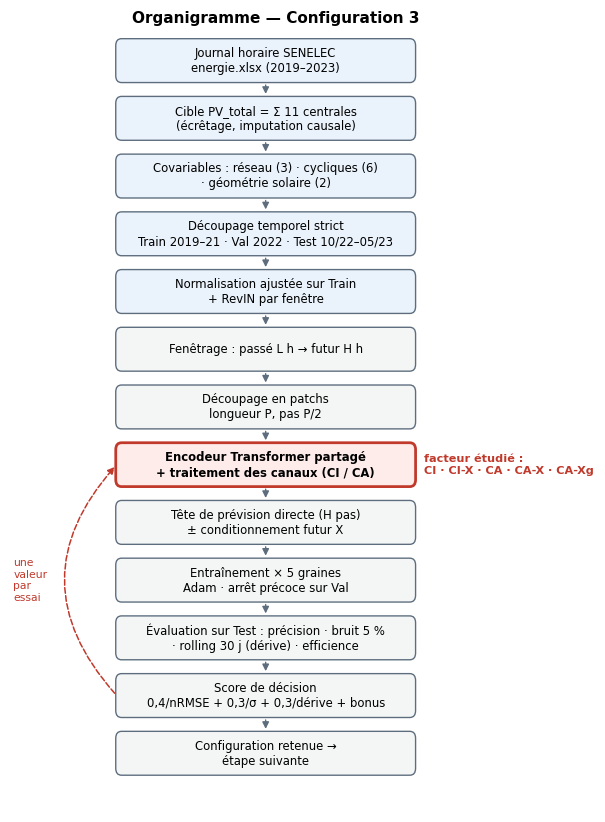

In [2]:
org.tracer(3, "Organigramme — Configuration 3", "org_config3")

## 2. Configurations évaluées

In [3]:
jeu = m.construire_jeu()
configs = configs_de(3)
pd.DataFrame([dict(nom=c.nom(), P=c.P, L=c.L, H=c.H, canaux=c.mode_canaux, futur_connu=c.futur_connu,
                   porte_physique=c.porte_physique, n_patchs=c.n_patchs) for c in configs])

,nom,P,L,H,canaux,futur_connu,porte_physique,n_patchs
0,PatchTST-CI_P12_L168_H24,12,168,24,CI,False,False,27
1,PatchTST-CIX_P12_L168_H24,12,168,24,CI,True,False,27
2,PatchTST-CA_P12_L168_H24,12,168,24,CA,False,False,27
3,PatchTST-CAX_P12_L168_H24,12,168,24,CA,True,False,27
4,PatchTST-CAXg_P12_L168_H24,12,168,24,CA,True,True,27


## 3. Entraînement et évaluation (5 graines chacune)

In [4]:
resultats = [m.evaluer_configuration(c, jeu) for c in configs]   # relit le cache s'il existe
detail = pd.DataFrame([dict(configuration=r["nom"], **{k: g[k] for k in
         ["graine", "epoques", "duree_s", "RMSE", "MAE", "nRMSE", "R2", "degradation_bruit", "drift_7j", "drift_J30_J1"]})
         for r in resultats for g in r["par_graine"]])
detail

,configuration,graine,epoques,duree_s,RMSE,MAE,nRMSE,R2,degradation_bruit,drift_7j,drift_J30_J1
0,PatchTST-CI_P12_L168_H24,0,13,871.6904,9.4293,5.6644,0.2130,0.9715,0.0000e+00,0.5874,0.5563
1,PatchTST-CI_P12_L168_H24,1,13,870.6330,9.4029,5.5093,0.2124,0.9716,0.0000e+00,0.5725,0.4917
2,PatchTST-CI_P12_L168_H24,2,8,25.7582,9.6188,5.4987,0.2173,0.9703,0.0000e+00,0.5651,0.5301
3,PatchTST-CI_P12_L168_H24,3,12,38.9990,9.4124,5.4662,0.2127,0.9716,0.0000e+00,0.5662,0.5478
4,PatchTST-CI_P12_L168_H24,4,9,28.7573,9.4748,5.2501,0.2141,0.9712,0.0000e+00,0.5458,0.5510
5,PatchTST-CIX_P12_L168_H24,0,17,56.5129,9.0164,5.2678,0.2037,0.9739,3.6213e-03,0.5912,0.5230
6,PatchTST-CIX_P12_L168_H24,1,20,68.5410,9.1419,5.3381,0.2065,0.9732,2.5127e-03,0.6318,0.5652
7,PatchTST-CIX_P12_L168_H24,2,20,67.7192,9.0923,5.5456,0.2054,0.9735,4.5106e-03,0.5844,0.5124
8,PatchTST-CIX_P12_L168_H24,3,10,33.4134,9.4059,5.5507,0.2125,0.9716,1.9504e-03,0.6340,0.5166
9,PatchTST-CIX_P12_L168_H24,4,25,84.1386,8.8887,5.3071,0.2008,0.9746,3.6989e-03,0.5848,0.5125


## 4. Tableau comparatif des métriques (moyenne sur 5 graines) et références naïves

In [5]:
tableau = m.tableau_comparatif(resultats)
_, vrai0, orig0 = an.charger_predictions(resultats[0]["nom"])
refs = an.lignes_references(jeu, orig0, vrai0, configs[0].H) if len({c.H for c in configs}) == 1 else None
colonnes = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_jour", "R2", "MBE", "degradation_bruit",
            "drift_J30_J1", "drift_7j", "inference_ms", "taille_Mo", "n_parametres", "score", "score_normalise", "rejete_bruit"]
affiche = pd.concat([tableau[colonnes], refs], ignore_index=True) if refs is not None else tableau[colonnes]
affiche.to_csv(m.DOSSIER_TABLEAUX / "tableau_config3.csv", index=False)
affiche.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_jour,R2,MBE,degradation_bruit,drift_J30_J1,drift_7j,inference_ms,taille_Mo,n_parametres,score,score_normalise,rejete_bruit
0,PatchTST-CI_P12_L168_H24,9.4676,0.0889,5.4778,0.2139,0.2294,0.9712,0.4551,0.0000,0.5354,0.5674,0.9184,0.4346,111066.0,5.9729,0.4000,False
1,PatchTST-CIX_P12_L168_H24,9.1091,0.1915,5.4019,0.2058,0.2146,0.9734,-0.5225,0.0033,0.5259,0.6052,1.1368,0.6580,169147.0,4.2062,0.5236,False
2,PatchTST-CA_P12_L168_H24,9.3863,0.2476,5.6622,0.2121,0.2207,0.9717,0.4390,-0.0003,0.5962,0.5885,2.5394,0.5031,128544.0,3.8078,0.1720,False
3,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625.0,5.7561,0.7839,False
4,PatchTST-CAXg_P12_L168_H24,9.0172,0.0944,5.2106,0.2037,0.2146,0.9739,-0.0161,1.1204,0.5777,0.5858,2.6275,0.7265,186625.0,5.8549,0.7885,True
5,Persistance J-1,10.3923,0.0000,4.9667,0.2348,NaN,0.9653,0.0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Moyenne 7 jours,10.8215,0.0000,5.3064,0.2445,NaN,0.9624,-0.0260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Lecture des colonnes.* `RMSE_std` : écart-type sur les 5 graines (robustesse). `nRMSE_jour` : nRMSE restreint aux heures
diurnes. `degradation_bruit` : hausse relative du RMSE sous bruit de 5 % sur les exogènes. `drift_J30_J1` : ratio brut de
`projet.md` (sensible à la nébulosité de deux journées isolées), `drift_7j` : ratio lissé retenu pour le score.
`score` : formule brute de `projet.md` ; `score_normalise` : chaque critère ramené à [0, 1] entre les variantes comparées.

In [6]:
dm = an.tests_dm(jeu, resultats)
dm.round(4)

,configuration,reference,skill_score,DM,p_valeur
0,PatchTST-CI_P12_L168_H24,persistance,0.0927,-2.0976,0.0360
1,PatchTST-CI_P12_L168_H24,moyenne 7 j,0.1287,-2.8080,0.0050
2,PatchTST-CIX_P12_L168_H24,persistance,0.1251,-2.9107,0.0036
3,PatchTST-CIX_P12_L168_H24,moyenne 7 j,0.1598,-2.9420,0.0033
4,PatchTST-CA_P12_L168_H24,persistance,0.1078,-2.4055,0.0162
5,PatchTST-CA_P12_L168_H24,moyenne 7 j,0.1432,-2.9732,0.0030
6,PatchTST-CAX_P12_L168_H24,persistance,0.1314,-2.9661,0.0030
7,PatchTST-CAX_P12_L168_H24,moyenne 7 j,0.1659,-3.0762,0.0021
8,PatchTST-CAXg_P12_L168_H24,persistance,0.1314,-2.9661,0.0030
9,PatchTST-CAXg_P12_L168_H24,moyenne 7 j,0.1659,-3.0762,0.0021


## 5. Chapelet des graines et stabilité sur 30 jours

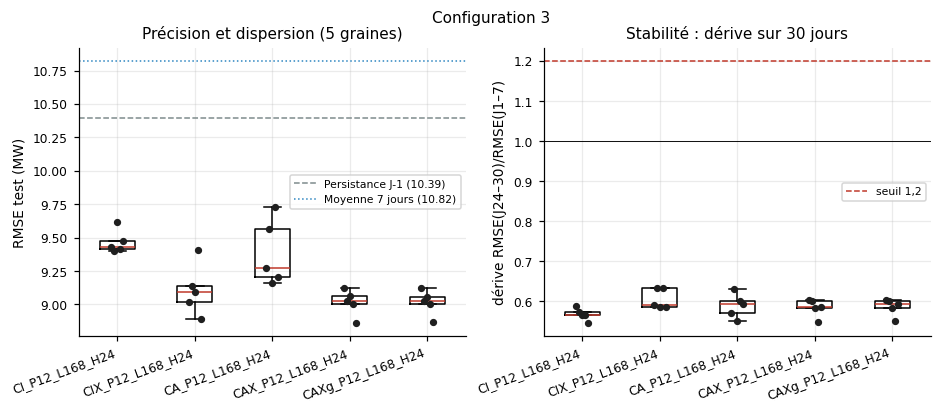

In [7]:
an.fig_chapelet(resultats, jeu, "fig_config3_chapelet", "Configuration 3")

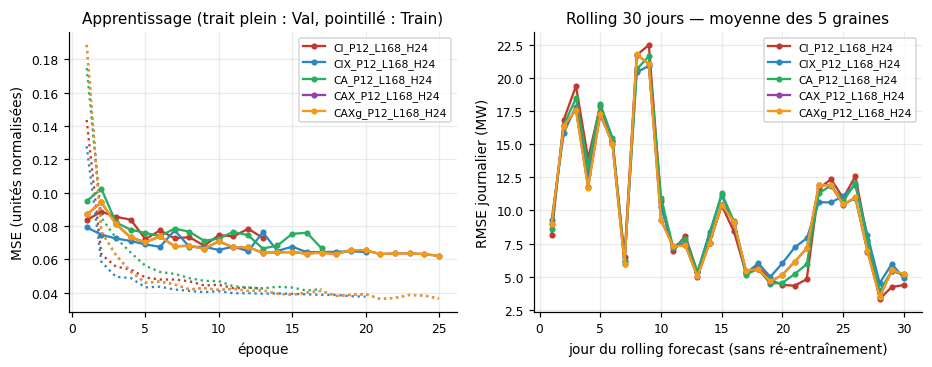

In [8]:
an.fig_apprentissage_et_derive(resultats, "fig_config3_apprentissage_derive")

## 6. Série observée vs prédite — meilleur modèle de la configuration

Configuration retenue : PatchTST-CAX_P12_L168_H24


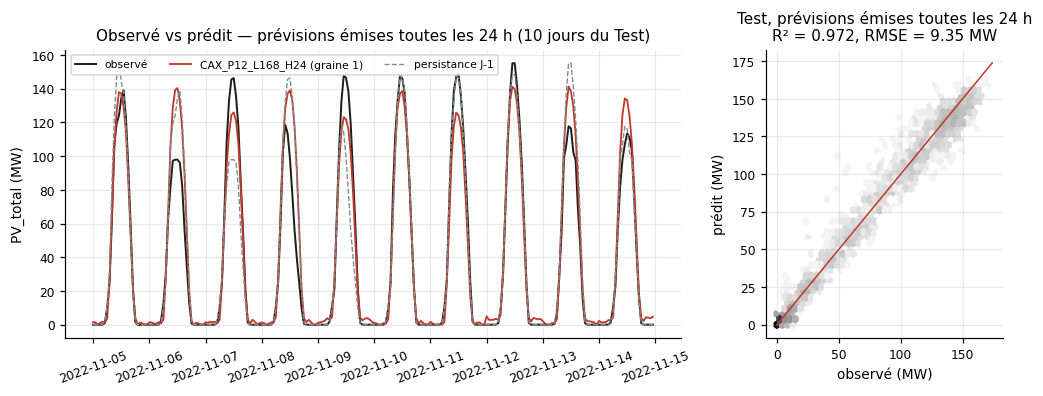

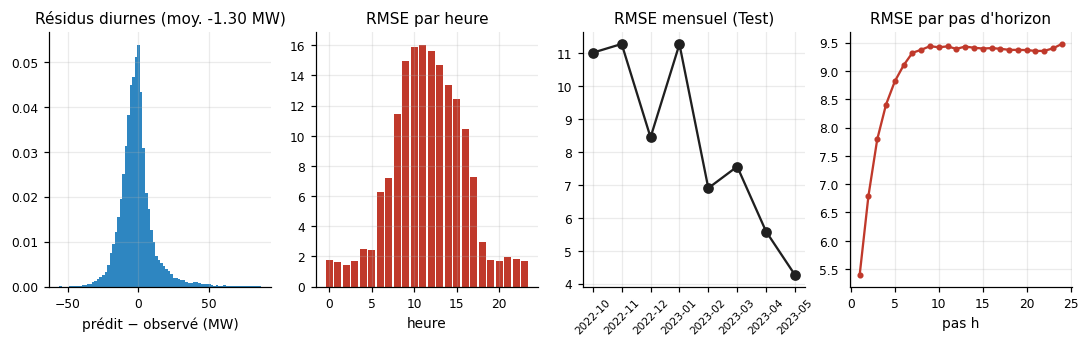

In [9]:
retenu = an.selection_precedente("config3_canaux")
print("Configuration retenue :", retenu)
res_retenu = [r for r in resultats if r["nom"] == retenu][0]
an.fig_observe_predit(res_retenu, jeu, "fig_config3_observe_predit")
an.fig_residus(res_retenu, jeu, "fig_config3_residus")

### Conclusion de la configuration 3

**Configuration retenue : `PatchTST-CAX_P12_L168_H24`** (score de décision normalisé = 0,784 ; score brut = 5,76).

- `PatchTST-CI_P12_L168_H24` : RMSE = 9,47 ± 0,09 MW, nRMSE = 0,214, gain vs persistance = +8,9 %, dégradation sous bruit = +0,0 %, dérive 7 j = 0,57, inférence = 0,9 ms, 111 066 paramètres.
- `PatchTST-CIX_P12_L168_H24` : RMSE = 9,11 ± 0,19 MW, nRMSE = 0,206, gain vs persistance = +12,3 %, dégradation sous bruit = +0,3 %, dérive 7 j = 0,61, inférence = 1,1 ms, 169 147 paramètres.
- `PatchTST-CA_P12_L168_H24` : RMSE = 9,39 ± 0,25 MW, nRMSE = 0,212, gain vs persistance = +9,7 %, dégradation sous bruit = -0,0 %, dérive 7 j = 0,59, inférence = 2,5 ms, 128 544 paramètres.
- `PatchTST-CAX_P12_L168_H24` : RMSE = 9,02 ± 0,10 MW, nRMSE = 0,204, gain vs persistance = +13,2 %, dégradation sous bruit = +0,4 %, dérive 7 j = 0,58, inférence = 2,9 ms, 186 625 paramètres.
- `PatchTST-CAXg_P12_L168_H24` : RMSE = 9,02 ± 0,09 MW, nRMSE = 0,204, gain vs persistance = +13,2 %, dégradation sous bruit = +112,0 %, dérive 7 j = 0,59, inférence = 2,6 ms, 186 625 paramètres.

- Écart de RMSE entre la meilleure et la moins bonne variante : 0,45 MW (5,0 %).
- Toutes les variantes respectent le critère de robustesse (dégradation < 15 %) : non ; toutes respectent l'objectif de dérive < 1,2 : oui ; toutes respectent l'efficience (< 100 ms, < 50 Mo) : oui.